<a href="https://colab.research.google.com/github/gyeongee/TIL/blob/main/%ED%9A%8C%EA%B7%80%EC%8B%A4%EC%8A%B5_%EC%9E%90%EC%A0%84%EA%B1%B0%EB%8C%80%EC%97%AC%EC%88%98%EC%9A%94%EC%98%88%EC%B8%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

캐글의 자전거 대여 수요 예측 경연에서 사용된 학습 데이터 세트를 이용해 선형 회귀와 트리 기반 회귀를 비교해보겠습니다.


데이터(https://www.kaggle.com/competitions/bike-sharing-demand/data)

해당 데이터 세트에는 2011년 1월부터 2012년 12월까지 날짜/시간,기온,습도,풍속 등의 정보를 기반으로 1시간 간격 동안의 자전거 대여 횟수가 기재돼 있습니다.

Data Fields
- datetime - hourly date + timestamp  
- season -  1 = 봄, 2 = 여름, 3 = 가을, 4 = 겨울
- holiday - 1 = 토,일요일의 주말을 제외한 국경일 등의 휴일, 0 = 휴일이 아닌 날
- workingday - 1 = 토,일요일의 주말 및 휴일이 아닌 주중, 0 = 주말 및 휴일   
- weather
  - 1: 맑음, 약간 구름 낀 흐림
  - 2: 안개, 안개+흐림
  - 3: 가벼운 눈, 가벼운 비 + 천둥
  - 4: 심한 눈/비, 천둥/번개
- temp - 온도(섭씨)
- atemp - 체감온도(섭씨)
- humidity - 상대습도
- windspeed - 풍속
- casual - 사전에 등록되지 않는 사용자가 대여한 횟수
- registered - 사전에 등록된 사용자가 대여한 횟수
- count - 대여 횟수




데이터 세트를 이용해 대여 횟수(count)를 예측해보겠습니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('/content/train.csv')
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [4]:
df.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

데이터 전처리와 시각화

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [8]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [12]:
# datetime으로 변경
import datetime

df['datetime']=pd.to_datetime(df['datetime'])
# 년도 피처 생성
df['year']=df['datetime'].dt.year
# 월 피처 생성
df['month']=df['datetime'].dt.month
# 일 피처 생성
df['day']=df['datetime'].dt.day
# 시간대 피처 생성
df['hour']=df['datetime'].dt.hour
# 요일 피처 생성
# 월요일=0, 일요일=6
df['dayofweek']=df['datetime'].dt.dayofweek

casual+registered = count 이므로 casual,registered 컬럼 삭제

In [13]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,dayofweek
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011,1,1,0,5
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011,1,1,1,5
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011,1,1,2,5
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011,1,1,3,5
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011,1,1,4,5


In [14]:
df.tail()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,year,month,day,hour,dayofweek
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012,12,19,19,2
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012,12,19,20,2
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012,12,19,21,2
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,2012,12,19,22,2
10885,2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88,2012,12,19,23,2


In [18]:
# datetime 컬럼 삭제
df.drop(['datetime','casual','registered'],axis=1,inplace=True)
df.columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'count', 'year', 'month', 'day', 'hour',
       'dayofweek'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      10886 non-null  int64  
 1   holiday     10886 non-null  int64  
 2   workingday  10886 non-null  int64  
 3   weather     10886 non-null  int64  
 4   temp        10886 non-null  float64
 5   atemp       10886 non-null  float64
 6   humidity    10886 non-null  int64  
 7   windspeed   10886 non-null  float64
 8   count       10886 non-null  int64  
 9   year        10886 non-null  int32  
 10  month       10886 non-null  int32  
 11  day         10886 non-null  int32  
 12  hour        10886 non-null  int32  
 13  dayofweek   10886 non-null  int32  
dtypes: float64(3), int32(5), int64(6)
memory usage: 978.2 KB


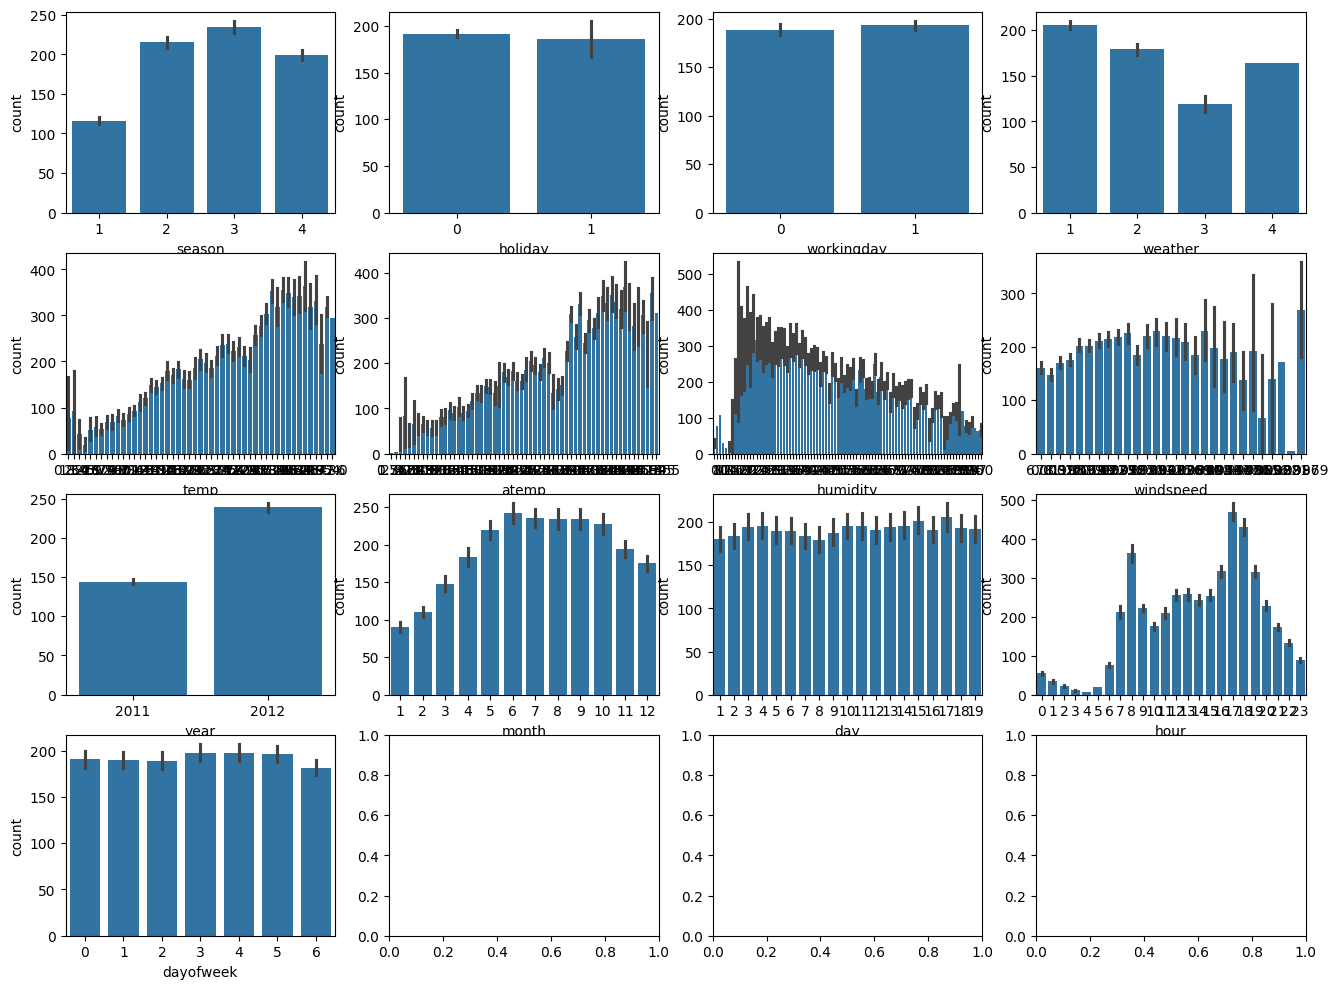

In [22]:
fig,axs = plt.subplots(figsize=(16,12),ncols=4,nrows=4)
cat_features=['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'year', 'month', 'day', 'hour',
       'dayofweek']
for i,feature in enumerate(cat_features):
  row = int(i/4)
  col=i%4
  sns.barplot(x=feature,y='count',data=df,ax=axs[row][col])

year(년도)별 count를 보면 2012년이 2011년보다 상대적으로 값이 높습니다. 이는 year 자체가 특별한 의미가 있어서라기보다는 시간이 지날수록 자전거 대여 횟수가 지속적으로 증가한 결과라고 여겨질 수 있습니다.

month(월별)의 경우 1,2,3월이 낮고, 6,7,8,9월이 높습니다. 또한 season(계절)을 보면 봄(1),겨울(4)이 낮고, 여름(2), 가을(3)이 높습니다.

weather(날씨)의 경우는 눈 또는 비가 있는 경우(3과 4)가 낮고, 맑거나(1) 약간 안개가 있는 경우(2)가 높습니다.

hour(시간)의 경우는 오전 출근 시간(8)과 오후 퇴근 시간(17,18)이 상대적으로 높습니다. day(일자)간의 차이는 크지 않으며, holiday(휴일 여부) 또는 workingday(주중여부)는 주중일 경우(즉, holiday는 0, workingday는 1)가 상대적으로 약간 높습니다.

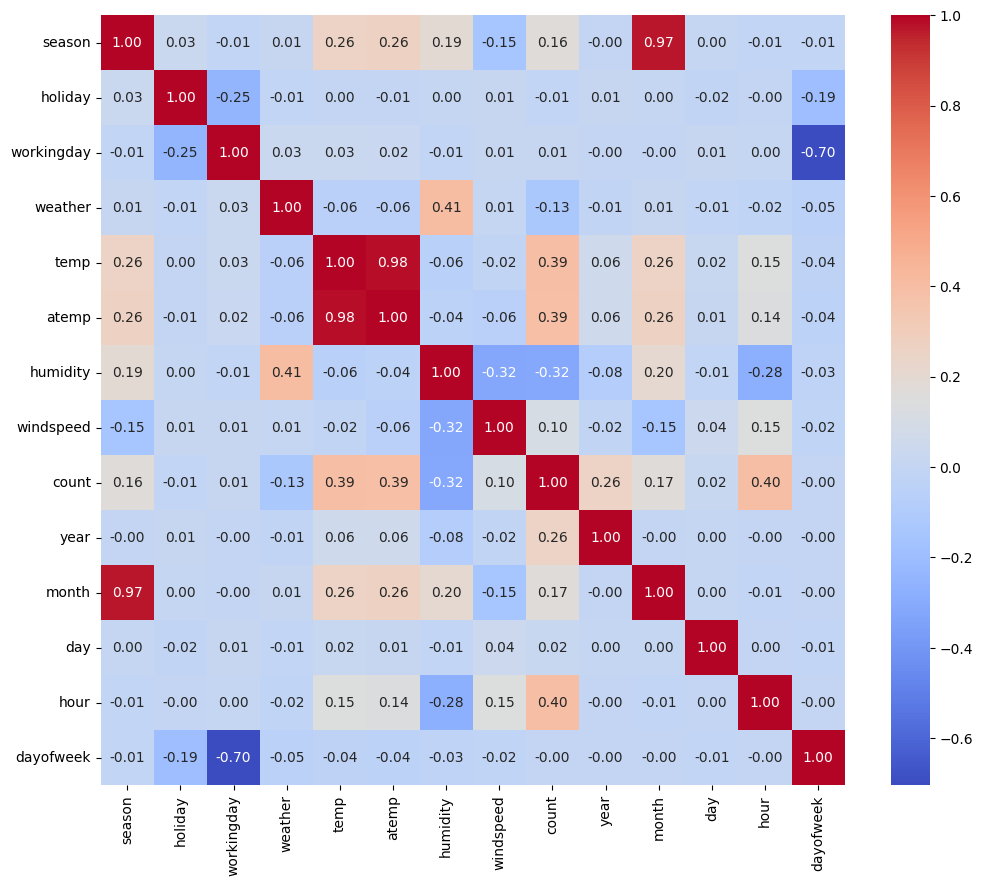

In [23]:
# 상관관계 확인
plt.figure(figsize=(12,10))

sns.heatmap(
    df.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)
plt.show(   )

season과 month의 상관관계가 높아서 season 삭제

dayofweek와 workingday의 상관관계가 높아서 dayofweek 삭제

temp와 atmep 중 temp 삭제

In [47]:
feature=['holiday', 'workingday', 'weather', 'atemp',
       'humidity', 'windspeed', 'year', 'month', 'day', 'hour',
       ]

X_features=df[feature]
X_features

,holiday,workingday,weather,atemp,humidity,windspeed,year,month,day,hour
0,0,0,1,14.395,81,0.0000,2011,1,1,0
1,0,0,1,13.635,80,0.0000,2011,1,1,1
2,0,0,1,13.635,80,0.0000,2011,1,1,2
3,0,0,1,14.395,75,0.0000,2011,1,1,3
4,0,0,1,14.395,75,0.0000,2011,1,1,4
...,...,...,...,...,...,...,...,...,...,...
10881,0,1,1,19.695,50,26.0027,2012,12,19,19
10882,0,1,1,17.425,57,15.0013,2012,12,19,20
10883,0,1,1,15.910,61,15.0013,2012,12,19,21
10884,0,1,1,17.425,61,6.0032,2012,12,19,22


In [39]:
# 캐글에서 요구한 성능평가 방법인 RMLSE 사용
from sklearn.metrics import mean_squared_error,mean_absolute_error

# log 값 변환 시 NaN 등의 이슈로 log()가 아닌 log1p()를 이용해 RMSLE 계산
def rmsle(y,pred):
  log_y = np.log1p(y)
  log_pred=np.log1p(pred)
  squared_error=(log_y - log_pred)**2
  rmsle=np.sqrt(np.mean(squared_error))
  return rmsle

# 사이킷런의 mean_square_error()를 이용해 RMSE 계산
def rmse(y,pred):
  return np.sqrt(mean_squared_error(y,pred))

# MSE,RMSE,RMSLE를 모두 계산
def evaluate_regr(y,pred):
  rmsle_val=rmsle(y,pred)
  rmse_val=rmse(y,pred)
  # MAE는 사이킷런의 mean_absolute_error()로 계산
  mae_val = mean_absolute_error(y,pred)
  print(f"RMSLE:{rmsle_val:.3f} ,RMSE:{rmse_val:.3f}, MAE:{mae_val:.3f}")

In [42]:
# rmsle 구현은 오버플로나 언더플로 오류가 발생하기 쉽습니다.
from sklearn.metrics import mean_squared_log_error

def rmsle(y,pred):
  pred = np.maximum(0,pred)
  msle=mean_squared_log_error(y,pred)
  rmsle_val=np.sqrt(msle)
  return rmsle_val

위의 rmsle() 를 구할 때 넘파이의 log()함수를 이용하거나 사이킷런의 mean_squared_log_error()를 이용할 수도 있지만 데이터 값의 크기에 따라 오버플로/언더플로 오류가 발생하기 쉽습니다.

따라서 log()보다는 log1p()를 이용하는데, log1p()의 경우는 1+log() 값으로 변환값에 1을 더하므로 이런 문제를 해결해 줍니다. 그리고 log1p()로 변환된 값은 다시 넘파이의 expm1() 함수로 쉽게 원래의 스케일로 복원될 수 있습니다.

로그 변환, 피처 인코딩과 모델 학습/예측/평가

In [48]:
# LinearRegression 객체를 이용해 회귀 예측 진행
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression,Ridge,Lasso

y_target=df['count']
X_train,X_test,y_train,y_test = train_test_split(X_features,y_target,test_size=0.2,random_state=0)

lr_reg = LinearRegression()
lr_reg.fit(X_train,y_train)
pred=lr_reg.predict(X_test)

evaluate_regr(y_test,pred)

RMSLE:1.299 ,RMSE:141.918, MAE:106.341


RMSLE:1.299 ,RMSE:141.918, MAE:106.341 는 실제 Target 데이터 값인 대여 횟수(count)를 감안하면 예측 오류로써 큰 값입니다. 실제 값과 예측값이 어느 정도 차이가 나는지 DataFrame의 칼럼으로 만들어서 오류 값이 가장 큰 수능로 5개만 확인해보겠습니다.

In [44]:
def get_top_error_data(y_test,pred,n_tops=5):
  # DataFrame의 칼럼으로 실제 대여 횟수(count)와 예측값을 서로 비교할 수 있도록 생성
  result_df = pd.DataFrame(y_test.values,columns=['real_count'])
  result_df['predicted_count']=np.round(pred)
  result_df['diff']=np.abs(result_df['real_count']-result_df['predicted_count'])

# 예측값과 실제 값이 가장 큰 데이터 순으로 출력
  print(result_df.sort_values('diff',ascending=False)[:n_tops])

get_top_error_data(y_test,pred,n_tops=5)

      real_count  predicted_count   diff
1618         890            324.0  566.0
966          884            329.0  555.0
412          745            198.0  547.0
454          721            177.0  544.0
1003         713            176.0  537.0


회귀에서 이렇게 큰 예측 오류가 발생할 경우 Target 값의 분포가 왜곡된 형태를 이루고 있을 수 있습니다

<Axes: >

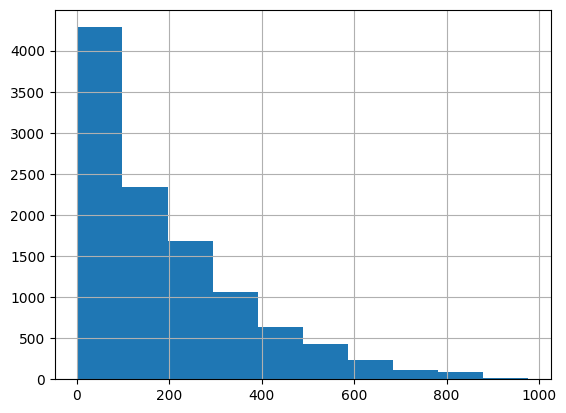

In [45]:
y_target.hist()

count 칼럼 값이 정규 분포가 아닌 0~200 사이에 왜곡돼 있는 것을 알 수 있습니다. 이렇게 왜곡된 값을 정규 분포 형태로 바꾸는 가장 일반적인 방법은 로그를 적용해 변환하는 것입니다.

<Axes: >

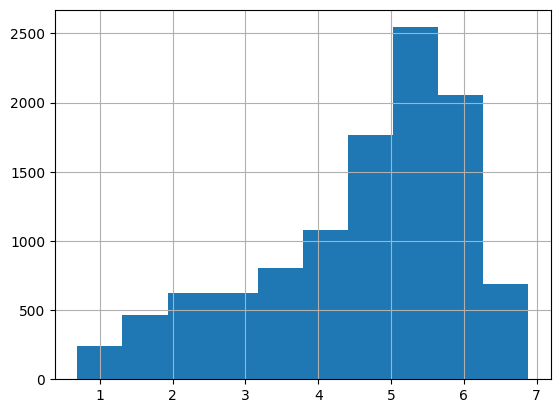

In [46]:
# target 값 log1p() 사용하여 변환하기
y_log_transform=np.log1p(y_target)
y_log_transform.hist()

로그 변환 적용 후 정규 분포 형태는 아니지만 변환하기 전보다는 왜곡 정도가 많이 향상됐습니다.

In [51]:
y_target_log=np.log1p(y_target)

# 로그 변환된 y_target_log를 반영해 학습/테스트 데이터 세트 분할
X_train,X_test,y_train,y_test = train_test_split(X_features,y_target_log,test_size=0.3,random_state=0)

lr_reg=LinearRegression()
lr_reg.fit(X_train,y_train)
pred=lr_reg.predict(X_test)

# 테스트 데이터 세트의 Target 값은 로그 변환됐으므로 다시 expm1을 이용해 원래 스케일로 변환
y_test_exp = np.expm1(y_test)

# 예측값 역시 로그 변환된 타깃 기반으로 학습돼 예측됐으르모 다시 expm1 스케일 변환
pred_exp=np.expm1(pred)

evaluate_regr(y_test_exp,pred_exp)

RMSLE:1.017 ,RMSE:162.620, MAE:109.227


<Axes: ylabel='None'>

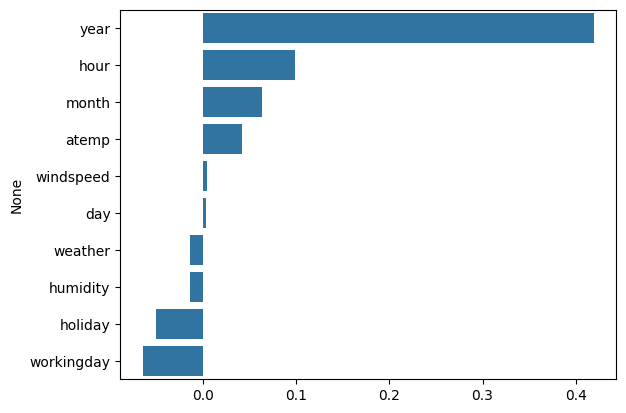

In [54]:
# 피처의 회귀 계숫값 시각화
coef = pd.Series(lr_reg.coef_,index=X_features.columns)
coef_sort=coef.sort_values(ascending=False)
sns.barplot(x=coef_sort.values,y=coef_sort.index)

year,hour,month,season,holiday,workingday 피처들의 회귀 계수 영향도가 상대적으로 높습니다.

카테고리형 피처들을 피처 인코딩에 원-핫 인코딩 적용해 변환하기


In [61]:
X_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   holiday     10886 non-null  int64  
 1   workingday  10886 non-null  int64  
 2   weather     10886 non-null  int64  
 3   atemp       10886 non-null  float64
 4   humidity    10886 non-null  int64  
 5   windspeed   10886 non-null  float64
 6   year        10886 non-null  int32  
 7   month       10886 non-null  int32  
 8   day         10886 non-null  int32  
 9   hour        10886 non-null  int32  
dtypes: float64(2), int32(4), int64(4)
memory usage: 680.5 KB


In [63]:
# get_dummies() 사용
X_features_ohe=pd.get_dummies(X_features,columns=['holiday','workingday','weather','year','month','day','hour'])


In [64]:
# 성능 평가 수치 반환 함수 생성
X_train,X_test,y_train,y_test = train_test_split(X_features_ohe,y_target_log,
                                                 test_size=0.3, random_state=0)

# 모델과 학습/테스트 데이터 세트를 입력하여 성능 평가 수치 반환
def get_model_predict(model,X_train,X_test,y_train,y_test,is_expm1=False):
  model.fit(X_train,y_train)
  pred=model.predict(X_test)
  if is_expm1:
    y_test=np.expm1(y_test)
    pred=np.expm1(pred)
  print(f'### {model.__class__.__name__} ###')
  evaluate_regr(y_test,pred)

# end of fuction get_model_predict

# 모델별로 평가 수행
lr_reg=LinearRegression()
ridge_reg=Ridge(alpha=10)
lasso_reg=Lasso(alpha=0.01)

for model in [lr_reg,ridge_reg,lasso_reg]:
  get_model_predict(model,X_train,X_test,y_train,y_test,is_expm1=True)

### LinearRegression ###
RMSLE:0.590 ,RMSE:97.503, MAE:63.332
### Ridge ###
RMSLE:0.590 ,RMSE:98.210, MAE:63.793
### Lasso ###
RMSLE:0.637 ,RMSE:114.094, MAE:73.427


원-핫 인코딩을 적용하고 나서 선형 회귀의 예측 성능이 많이 향상되었습니다.

<Axes: ylabel='None'>

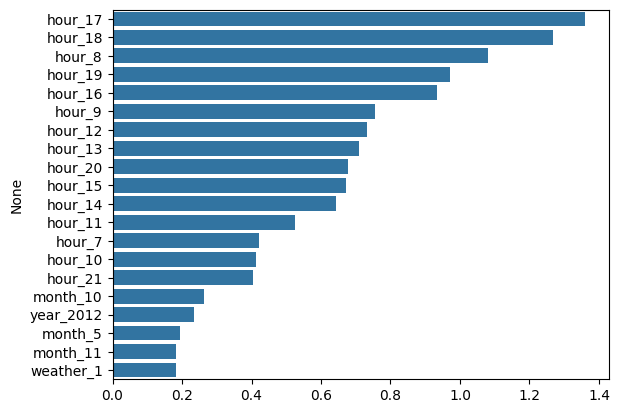

In [65]:
coef = pd.Series(lr_reg.coef_,index=X_features_ohe.columns)
coef_sort=coef.sort_values(ascending=False)[:20]
sns.barplot(x=coef_sort.values,y=coef_sort.index)

In [67]:
# 회귀트리를 이용해 회귀 예측을 수행
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 랜덤 포레스트, GBM,XGBoost, LightGBM model 별로 평가 수행
rf_reg = RandomForestRegressor(n_estimators=500)
gbm_reg=GradientBoostingRegressor(n_estimators=500)
xgb_reg=XGBRegressor(n_estimators=500)
lgbm_reg=LGBMRegressor(n_estimators=500)

for model in [rf_reg,gbm_reg,xgb_reg,lgbm_reg]:
  get_model_predict(model,X_train.values,X_test.values,y_train.values,
                    y_test.values,is_expm1=True)

### RandomForestRegressor ###
RMSLE:0.363 ,RMSE:51.654, MAE:31.899
### GradientBoostingRegressor ###
RMSLE:0.351 ,RMSE:58.066, MAE:36.056
### XGBRegressor ###
RMSLE:0.341 ,RMSE:53.180, MAE:31.582
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000807 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 291
[LightGBM] [Info] Number of data points in the train set: 7620, number of used features: 67
[LightGBM] [Info] Start training from score 4.582043
### LGBMRegressor ###
RMSLE:0.320 ,RMSE:46.885, MAE:28.834


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


앞선 선형 회귀 모델보다 회귀 예측 성능이 개선됐습니다. 하지만 이것이 회귀 트리가 선형 회귀보다 더 나은 성능을 가진다는 의미는 아닙니다. 데이터 세트의 유형에 따라 결과는 얼마든지 달라질 수 있습니다.